In [41]:
import torch

In [42]:
import math

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [44]:
'''
    I borrow these values from the paper.
    In particular, I use one of the std dev they found
        for their natural images dataset
        during the image regression task
        through hyper-parameter sweep.
    I did not redo the hyper-param sweep
    and I don't know if these values are optimal!
'''
channels = 256 #Pg 8
freq = 256 # Pg 8
sig_pos = 6. # Pg 19
sig_gaus = 10. # Pg 19

In [45]:
'''
    I've modified a few of these funcs so that they take more than just v
    for example, I've unfixed atens/btens in the general form
''' 

"\n    I've modified a few of these funcs so that they take more than just v\n    for example, I've unfixed atens/btens in the general form\n"

In [46]:
def general(v: torch.Tensor, atens: torch.Tensor, btens: torch.Tensor):
    '''
    This func never gets used.
    Rather, it's the general form that the rest of the funcs take after.
    '''
    muls = btens @ v
    circle = 2 * math.pi * muls
    coses = torch.cos(circle)
    sins = torch.sin(circle)
    scaled_coses = atens * coses
    scaled_sins = atens * sins
    pairs = torch.stack((scaled_coses, scaled_sins), dim=1)
    interleaved = pairs.flatten()
    return interleaved

In [47]:
'''
    I've also modified the rest of these to be able to take multiple vs
    so that I can compute the feature's for each dataset in one call
'''

"\n    I've also modified the rest of these to be able to take multiple vs\n    so that I can compute the feature's for each dataset in one call\n"

In [48]:
def basic(v: torch.Tensor):
    '''
    I think this basic mapping technically breaks from the general form?
    It doesn't interleave coses/sins, rather it returns big cos/sin blocks.
    '''
    circle = 2 * math.pi * v
    cos = torch.cos(circle)
    sin = torch.sin(circle)
    return torch.cat((cos, sin), dim=-1)

In [49]:
def positional_encoding(v: torch.Tensor, sigma: float, m: int, dev: torch.device):
    js = torch.arange(m).to(dev)
    fracs = js/m
    sigmas = sigma**fracs
    coeffs = 2 * math.pi * sigmas
    circle = coeffs.unsqueeze(0).unsqueeze(-1) * v.unsqueeze(-2)
    coses = torch.cos(circle)
    sins = torch.sin(circle)
    combine = torch.stack((coses, sins), dim=-2)
    v_groups = combine.view(-1, 2*m, v.size(-1))
    return v_groups

In [50]:
def gaussian(v: torch.Tensor, sigma: float, m: int, dev: torch.device):
    B = torch.normal(0., sigma, (m, v.size(-1))).to(dev) # mu taken from pg 7
    muls = B @ v.unsqueeze(-1)
    muls = muls.squeeze(-1)
    circle = 2 * math.pi * muls
    coses = torch.cos(circle)
    sins = torch.sin(circle)
    return torch.cat((coses, sins), dim=-1)

In [51]:
import torch.nn as nn
import torch.optim as optim

In [52]:
criterion = nn.MSELoss()

In [53]:
import torchvision

In [54]:
vid_dir = "/kaggle/working/"

In [55]:
!rm -rf {vid_dir}*
!mkdir {vid_dir}nm
!mkdir {vid_dir}basic
!mkdir {vid_dir}pos
!mkdir {vid_dir}gaus

In [56]:
mona = torchvision.transforms.functional.convert_image_dtype(torchvision.io.read_image("/kaggle/input/monalisaimage/test.jpg"), torch.float32)
inner_color = mona.permute(1,2,0)
xs = torch.linspace(0, 1, inner_color.size(1))
ys = torch.linspace(0, 1, inner_color.size(0))
grid_tuples = torch.meshgrid(xs, ys, indexing='xy')
grid = torch.stack(grid_tuples).permute(1, 2, 0).to(device)
labels = inner_color.reshape(inner_color.size(0) * inner_color.size(1), 3).to(device)

In [57]:
nm_input = grid.detach().clone().reshape(grid.size(0) * grid.size(1), 2)

In [58]:
'''
    4 layers with ReLU in between and Sigmoid output,
    Same as used for the image regression task in the paper.
    Though I am not actually reproducing their image regression experiments.
'''
no_map = nn.Sequential(
    nn.Linear(in_features=2, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=3),
    nn.Sigmoid()
).to(device)

optimizer = optim.Adam(no_map.parameters(), lr=10**-2) # Lr Pg 19

In [59]:
'''
    I think it's a bit weird to call this an epoch?
    But, I really can load the entire single-image dataset
    and do inference on the whole thing
    and do every optim step (of which there is only one)
    in a single go, so it seems, to me, like these are epochs!
'''
for epoch in range(1000):
    epoch_loss = 0.0

    pred = no_map(nm_input)
    loss = criterion(pred, labels)
    
    epoch_loss = loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    img = pred.reshape(512,343,3).permute(2,0,1).detach().cpu()
    torchvision.utils.save_image(img, f"{vid_dir}nm/{epoch:04d}_loss_{epoch_loss:.6f}.png")
    print(epoch)
    print(epoch_loss)

0
0.0837690606713295
1
0.04387509077787399
2
0.04199793562293053
3
0.029209354892373085
4
0.03067251481115818
5
0.029262591153383255
6
0.024077512323856354
7
0.02528941072523594
8
0.024581078439950943
9
0.022975057363510132
10
0.022994108498096466
11
0.023309873417019844
12
0.022625815123319626
13
0.022200526669621468
14
0.022415034472942352
15
0.022120941430330276
16
0.021213382482528687
17
0.0206907968968153
18
0.020647600293159485
19
0.020402932539582253
20
0.02017110399901867
21
0.020435431972146034
22
0.020510384812951088
23
0.020192334428429604
24
0.02005695179104805
25
0.020016895607113838
26
0.01983475312590599
27
0.019777925685048103
28
0.019818015396595
29
0.01962239481508732
30
0.01950197108089924
31
0.019478240981698036
32
0.019320955500006676
33
0.019278617575764656
34
0.019215842708945274
35
0.01912177912890911
36
0.019084637984633446
37
0.01901112124323845
38
0.018943561241030693
39
0.018867025151848793
40
0.01876959018409252
41
0.018673179671168327
42
0.0186014492064714

In [60]:
learned = no_map(nm_input.to(device))

In [61]:
img = learned.view(512, 343, 3).detach().cpu()

In [62]:
import matplotlib.pyplot as plt

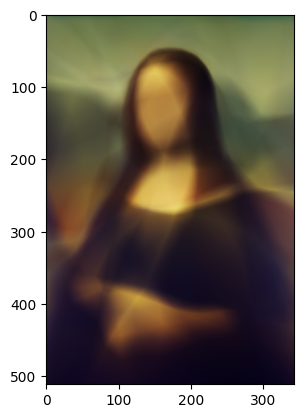

In [63]:
plt.imshow(img.numpy())
plt.show()

In [64]:
torchvision.utils.save_image(img.permute(2, 0, 1), "new.png")

In [65]:
b_input = basic(grid).detach().view(512 * 343, 4)

In [66]:
basic_map = nn.Sequential(
    nn.Linear(in_features=4, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=3),
    nn.Sigmoid()
).to(device)

optimizer = optim.Adam(basic_map.parameters(), lr=10**-2)

In [67]:
for epoch in range(1000):
    epoch_loss = 0.0

    pred = basic_map(b_input)
    loss = criterion(pred, labels)
    
    epoch_loss = loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    img = pred.reshape(512,343,3).permute(2,0,1).detach().cpu()
    torchvision.utils.save_image(img, f"{vid_dir}basic/{epoch:04d}_loss_{epoch_loss:.6f}.png")
    print(epoch)
    print(epoch_loss)

0
0.08576105535030365
1
0.051239289343357086
2
0.039875250309705734
3
0.03293294832110405
4
0.0256981048732996
5
0.030143573880195618
6
0.027603598311543465
7
0.023942936211824417
8
0.024249037727713585
9
0.024408403784036636
10
0.022782476618885994
11
0.021396702155470848
12
0.02166134864091873
13
0.021957729011774063
14
0.021403629332780838
15
0.0206855870783329
16
0.019775791093707085
17
0.019258514046669006
18
0.01911277510225773
19
0.01889883726835251
20
0.018535524606704712
21
0.018159007653594017
22
0.017759084701538086
23
0.017258914187550545
24
0.01676870696246624
25
0.01636585220694542
26
0.015906663611531258
27
0.015457452274858952
28
0.015118966810405254
29
0.014663886278867722
30
0.01404924038797617
31
0.013512203469872475
32
0.013094556517899036
33
0.012621046043932438
34
0.012068716809153557
35
0.011603760533034801
36
0.011258991435170174
37
0.010826260782778263
38
0.010409828275442123
39
0.010040082968771458
40
0.009695002809166908
41
0.009365445002913475
42
0.009060157

In [68]:
learned = basic_map(b_input.to(device))

In [69]:
img = learned.view(512, 343, 3).detach().cpu()

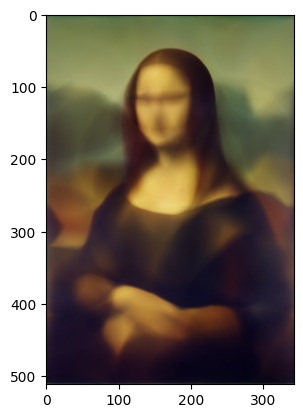

In [70]:
plt.imshow(img.numpy())
plt.show()

In [71]:
pos_input = positional_encoding(grid, sig_pos, freq, device).detach().view(512 * 343, 1024)

In [72]:
pos_map = nn.Sequential(
    nn.Linear(in_features=1024, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=3),
    nn.Sigmoid()
).to(device)

optimizer = optim.Adam(pos_map.parameters(), lr=10**-3)

In [73]:
for epoch in range(1000):
    epoch_loss = 0.0

    pred = pos_map(pos_input)
    loss = criterion(pred, labels)
    
    epoch_loss = loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    img = pred.reshape(512,343,3).permute(2,0,1).detach().cpu()
    torchvision.utils.save_image(img, f"{vid_dir}pos/{epoch:04d}_loss_{epoch_loss:.6f}.png")
    print(epoch)
    print(epoch_loss)

0
0.09275714308023453
1
0.07978474348783493
2
0.06629081070423126
3
0.04985501989722252
4
0.03328603133559227
5
0.02385137416422367
6
0.02517686039209366
7
0.027497094124555588
8
0.02542603574693203
9
0.02121102251112461
10
0.017522718757390976
11
0.015477335080504417
12
0.014723804779350758
13
0.014256535097956657
14
0.013466882519423962
15
0.01238856092095375
16
0.01134472619742155
17
0.010582166723906994
18
0.010129646398127079
19
0.009833338670432568
20
0.00950950849801302
21
0.009101704694330692
22
0.00869379099458456
23
0.008380341343581676
24
0.008130600675940514
25
0.007822518236935139
26
0.00744547788053751
27
0.007129109464585781
28
0.006923312321305275
29
0.006704567465931177
30
0.0063970996998250484
31
0.006102927029132843
32
0.005945557728409767
33
0.005879209376871586
34
0.0057486132718622684
35
0.0055276500061154366
36
0.005320688243955374
37
0.005177142098546028
38
0.005053319036960602
39
0.004926761612296104
40
0.00482502207159996
41
0.004738879390060902
42
0.004631461

In [74]:
learned = pos_map(pos_input.to(device))

In [75]:
img = learned.view(512, 343, 3).detach().cpu()

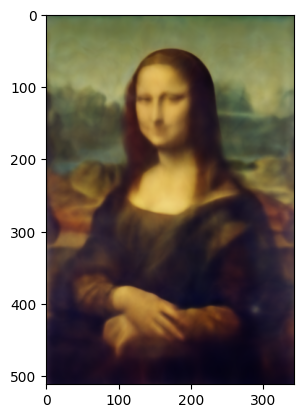

In [76]:
plt.imshow(img.numpy())
plt.show()

In [77]:
gaus_input = gaussian(grid, sig_gaus, freq, device).detach().view(512 * 343, 512)

In [78]:
gaus_map = nn.Sequential(
    nn.Linear(in_features=512, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=channels),
    nn.ReLU(),
    nn.Linear(in_features=channels, out_features=3),
    nn.Sigmoid()
).to(device)

optimizer = optim.Adam(gaus_map.parameters(), lr=10**-3)

In [79]:
for epoch in range(1000):
    epoch_loss = 0.0

    pred = gaus_map(gaus_input)
    loss = criterion(pred, labels)
    
    epoch_loss = loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    img = pred.reshape(512,343,3).permute(2,0,1).detach().cpu()
    torchvision.utils.save_image(img, f"{vid_dir}gaus/{epoch:04d}_loss_{epoch_loss:.6f}.png")
    print(epoch)
    print(epoch_loss)

0
0.08181946724653244
1
0.07307939976453781
2
0.06418713927268982
3
0.05442360043525696
4
0.04437863081693649
5
0.03584180772304535
6
0.031621601432561874
7
0.03321828693151474
8
0.036600250750780106
9
0.03729807585477829
10
0.03525931015610695
11
0.031995996832847595
12
0.02896265871822834
13
0.026976093649864197
14
0.02608012780547142
15
0.025845486670732498
16
0.02576974406838417
17
0.025494281202554703
18
0.02485791966319084
19
0.02387399971485138
20
0.022687064483761787
21
0.021514756605029106
22
0.02057010494172573
23
0.019968798384070396
24
0.019666237756609917
25
0.019480090588331223
26
0.019197259098291397
27
0.018688291311264038
28
0.01795710064470768
29
0.017114698886871338
30
0.016309117898344994
31
0.015651138499379158
32
0.015169225633144379
33
0.014808923937380314
34
0.014471713453531265
35
0.014070502482354641
36
0.013570570386946201
37
0.012998100370168686
38
0.012418492697179317
39
0.01189843937754631
40
0.011468540877103806
41
0.011107727885246277
42
0.01075855456292

In [80]:
learned = gaus_map(gaus_input.to(device))

In [81]:
img = learned.view(512, 343, 3).detach().cpu()

In [82]:
import matplotlib.pyplot as plt

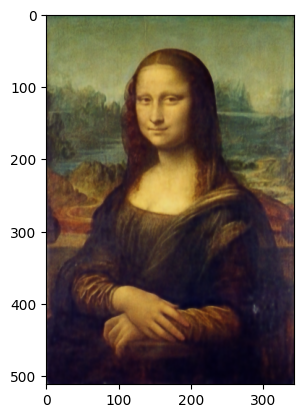

In [83]:
plt.imshow(img.numpy())
plt.show()

In [84]:
!touch {vid_dir}/test.txt

In [85]:
!zip -r "{vid_dir}/images.zip" "{vid_dir}" -x "{vid_dir}/images.zip" "{vid_dir}/images.zip/*"

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/gaus/ (stored 0%)
  adding: kaggle/working/gaus/0459_loss_0.001057.png (deflated 0%)
  adding: kaggle/working/gaus/0744_loss_0.000928.png (deflated 0%)
  adding: kaggle/working/gaus/0996_loss_0.000878.png (deflated 0%)
  adding: kaggle/working/gaus/0657_loss_0.000979.png (deflated 0%)
  adding: kaggle/working/gaus/0225_loss_0.001218.png (deflated 0%)
  adding: kaggle/working/gaus/0738_loss_0.000934.png (deflated 0%)
  adding: kaggle/working/gaus/0012_loss_0.028963.png (deflated 0%)
  adding: kaggle/working/gaus/0342_loss_0.001116.png (deflated 0%)
  adding: kaggle/working/gaus/0198_loss_0.001252.png (deflated 0%)
  adding: kaggle/working/gaus/0836_loss_0.000935.png (deflated 0%)
  adding: kaggle/working/gaus/0603_loss_0.001030.png (deflated 0%)
  adding: kaggle/working/gaus/0302_loss_0.001146.png (deflated 0%)
  adding: kaggle/working/gaus/0917_loss_0.000931.png (deflated 0%)
  adding: kaggle/working/gaus/0331_loss_0.001129